# Seller Performance: Where Bad Customer Experiences Come From

**Dataset:** Brazilian e-commerce marketplace, ~100k orders, Sept 2016 – Aug 2018.

**Two questions:**

1. **How concentrated is the damage across sellers?** (the worst 5% of sellers)
2. **Are certain sellers a recurring source of bad experiences regardless of category or delivery time?**


A "bad experience" is a review of 1 or 2 stars out of 5.

## Importing Libs and defaults

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)

plt.rcParams.update({"figure.figsize": (8, 4), "figure.dpi": 100,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#999999"  
DATA = Path("E-Commerce Dataset ")                    
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)      
print("ready")

ready


# Load and view the data

In [2]:
orders    = pd.read_csv(DATA / "orders_dataset.csv", parse_dates=[
                "order_purchase_timestamp", "order_delivered_carrier_date",
                "order_delivered_customer_date", "order_estimated_delivery_date"])
items     = pd.read_csv(DATA / "order_items_dataset.csv")
reviews   = pd.read_csv(DATA / "order_reviews_dataset.csv", parse_dates=["review_creation_date"])
products  = pd.read_csv(DATA / "products_dataset.csv")
sellers   = pd.read_csv(DATA / "sellers_dataset.csv")
cats      = pd.read_csv(DATA / "product_category_name_translation.csv")

for name, df in [("orders", orders), ("order_items", items), ("reviews", reviews),
                 ("products", products), ("sellers", sellers)]:
    print(f"{name:12s} {len(df):>7,} rows  {df.shape[1]:>2} columns")

orders        99,441 rows   8 columns
order_items  112,650 rows   7 columns
reviews       99,224 rows   7 columns
products      32,951 rows   9 columns
sellers        3,095 rows   4 columns


In [3]:
# Preview the two most important tables.
display(orders.head(3))
display(items.head(3))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [4]:
# Check missing values in the columns we will rely on.
cols = ["order_status", "order_purchase_timestamp", "order_delivered_customer_date",
        "order_estimated_delivery_date"]
print("orders - missing values:")
print(orders[cols].isna().sum().to_string())
print(f"\nreviews - missing review_score: {reviews.review_score.isna().sum()}")
print(f"products - missing category    : {products.product_category_name.isna().sum()}")

orders - missing values:
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    2965
order_estimated_delivery_date       0

reviews - missing review_score: 0
products - missing category    : 610


## 3. Data quality checks that decide how we clean

In [5]:
# Check 1: how many orders were actually delivered? Undelivered orders measure a different problem.
print(orders.order_status.value_counts().to_string())
print(f"\ndelivered share: {(orders.order_status == 'delivered').mean():.1%}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

delivered share: 97.0%


In [6]:
# Check 2: reviews belong to an ORDER, but sellers belong to an ITEM - how often is that ambiguous?
sellers_per_order = items.groupby("order_id").seller_id.nunique()
print(sellers_per_order.value_counts().sort_index().to_string())
print(f"\norders with exactly one seller: {(sellers_per_order == 1).mean():.1%}")
print("-> we keep single-seller orders so every review belongs to exactly one seller")

seller_id
1    97388
2     1219
3       54
4        3
5        2

orders with exactly one seller: 98.7%
-> we keep single-seller orders so every review belongs to exactly one seller


In [7]:
# Check 3: are the multi-seller orders we drop unusual? (they are, badly - worth knowing)
tmp = (orders[orders.order_status == "delivered"]
       .merge(reviews[["order_id", "review_score"]].drop_duplicates("order_id"), on="order_id")
       .merge(sellers_per_order.rename("n_sellers"), on="order_id"))
tmp["is_bad"] = tmp.review_score <= 2
print(tmp.groupby(tmp.n_sellers > 1).is_bad.agg(orders="size", bad_rate="mean").to_string())
print("\n-> multi-seller orders are far worse; noted as a separate issue, not a seller-quality one")

           orders  bad_rate
n_sellers                  
False       94571  0.123410
True         1261  0.472641

-> multi-seller orders are far worse; noted as a separate issue, not a seller-quality one


In [8]:
# Check 4: some orders have more than one review row - we will keep the latest.
print(f"review rows      : {len(reviews):,}")
print(f"unique order_ids : {reviews.order_id.nunique():,}")
print(f"duplicate rows   : {reviews.order_id.duplicated().sum():,}")

review rows      : 99,224
unique order_ids : 98,673
duplicate rows   : 551


## 4. Cleaning

In [9]:
# Apply the four cleaning rules and print how many orders survive each one.
reviews_clean = (reviews.sort_values("review_creation_date")
                 .drop_duplicates("order_id", keep="last"))          # rule 1: latest review only
single = sellers_per_order[sellers_per_order == 1].index             # rule 2: single-seller only

print(f"raw orders                    : {len(orders):>7,}")
df = orders[orders.order_status == "delivered"]                      # rule 3: delivered only
print(f"delivered                     : {len(df):>7,}")
df = df[df.order_id.isin(single)]
print(f"single-seller                 : {len(df):>7,}")
df = df.merge(reviews_clean[["order_id", "review_score"]], on="order_id")
print(f"has a review                  : {len(df):>7,}")
df = df.dropna(subset=["order_delivered_customer_date"])             # rule 4: needs a delivery date
print(f"has a delivery date  (= base) : {len(df):>7,}")

raw orders                    :  99,441
delivered                     :  96,478
single-seller                 :  95,203
has a review                  :  94,571
has a delivery date  (= base) :  94,563


In [10]:
# Attach seller, order value and product category to each order.
order_info = (items.groupby("order_id")
              .agg(seller_id=("seller_id", "first"), gmv=("price", "sum"))
              .reset_index())
top_product = items.sort_values("price", ascending=False).drop_duplicates("order_id")

df = (df.merge(order_info, on="order_id")
        .merge(top_product[["order_id", "product_id"]], on="order_id")
        .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
        .merge(cats, on="product_category_name", how="left")
        .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left"))
df["category"] = df.product_category_name_english.fillna("unknown")

print(f"clean base: {len(df):,} orders, {df.seller_id.nunique():,} sellers")
print(f"date range: {df.order_purchase_timestamp.min():%Y-%m-%d} to "
      f"{df.order_purchase_timestamp.max():%Y-%m-%d}")

clean base: 94,563 orders, 2,944 sellers
date range: 2016-09-15 to 2018-08-29


## 5. Preprocessing: build the columns the analysis needs

In [11]:
# Create the outcome flag, the delivery-delay measures, and a delay band for each order.
df["is_bad"]     = df.review_score <= 2                                        # the outcome
df["delay_days"] = (df.order_delivered_customer_date
                    - df.order_estimated_delivery_date).dt.days                # + = late
df["is_late"]    = df.delay_days > 0
df["band"] = pd.cut(df.delay_days, [-np.inf, -10, -3, 0, 3, 10, np.inf],
                    labels=["10+ d early", "3-10 d early", "0-3 d early",
                            "0-3 d late", "3-10 d late", "10+ d late"])

BAD_RATE = df.is_bad.mean()
print(f"bad-review rate : {BAD_RATE:.2%}  ({df.is_bad.sum():,} bad reviews)")
print(f"late-delivery rate: {df.is_late.mean():.2%}")
df[["review_score", "is_bad", "delay_days", "is_late", "band", "category"]].head()

bad-review rate : 12.35%  (11,676 bad reviews)
late-delivery rate: 6.74%


,review_score,is_bad,delay_days,is_late,band,category
0,4,False,-8,False,3-10 d early,housewares
1,4,False,-6,False,3-10 d early,perfumery
2,5,False,-18,False,10+ d early,auto
3,5,False,-13,False,10+ d early,pet_shop
4,5,False,-10,False,10+ d early,stationery


In [12]:
# Validate the clean base before analysing it.
assert df.order_id.is_unique,                  "duplicate orders"
assert df.review_score.between(1, 5).all(),    "review score out of range"
assert df.seller_id.notna().all(),             "missing seller"
assert df.delay_days.notna().all(),            "missing delay"
print("all checks passed")

all checks passed


## 6. EDA

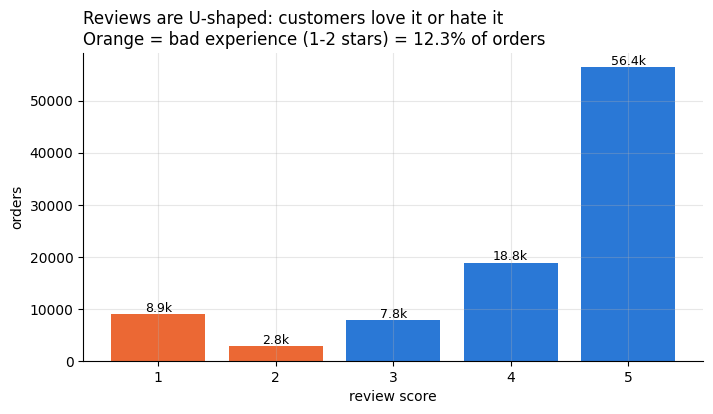

In [13]:
# EDA 1: how are review scores distributed? (this justifies using 1-2 stars, not the average)
counts = df.review_score.value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values, color=[ORANGE, ORANGE, BLUE, BLUE, BLUE])
for x, y in counts.items():
    ax.annotate(f"{y/1000:.1f}k", (x, y), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("review score"); ax.set_ylabel("orders"); ax.set_xticks([1, 2, 3, 4, 5])
ax.set_title("Reviews are U-shaped: customers love it or hate it\n"
             f"Orange = bad experience (1-2 stars) = {BAD_RATE:.1%} of orders", loc="left")
plt.savefig(FIGS / "eda1_review_scores.png", bbox_inches="tight"); plt.show()

              orders  bad_rate
band                          
10+ d early    60453     0.082
3-10 d early   23488     0.095
0-3 d early     4253     0.115
0-3 d late      1846     0.320
3-10 d late     2498     0.715
10+ d late      2025     0.789


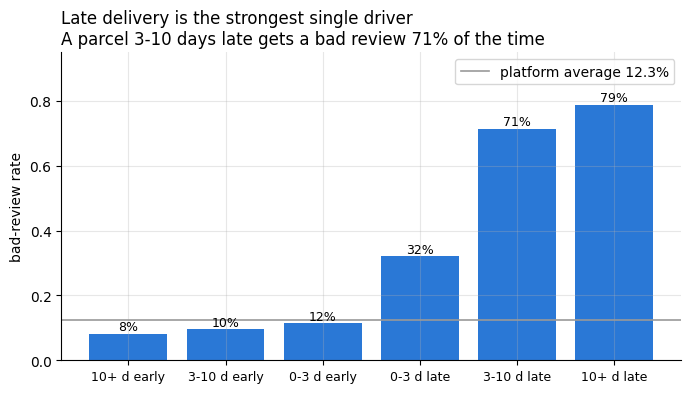

In [14]:
# EDA 2: how much does late delivery drive bad reviews? (this is the biggest single factor)
band_tbl = df.groupby("band", observed=True).is_bad.agg(orders="size", bad_rate="mean")
print(band_tbl.to_string(float_format=lambda v: f"{v:,.3f}"))

fig, ax = plt.subplots()
ax.bar(range(len(band_tbl)), band_tbl.bad_rate, color=BLUE)
for i, v in enumerate(band_tbl.bad_rate):
    ax.annotate(f"{v:.0%}", (i, v), ha="center", va="bottom", fontsize=9)
ax.axhline(BAD_RATE, color=GREY, lw=1.2, label=f"platform average {BAD_RATE:.1%}")
ax.set_xticks(range(len(band_tbl))); ax.set_xticklabels(band_tbl.index, fontsize=9)
ax.set_ylabel("bad-review rate"); ax.set_ylim(0, 0.95); ax.legend()
ax.set_title("Late delivery is the strongest single driver\n"
             "A parcel 3-10 days late gets a bad review 71% of the time", loc="left")
plt.savefig(FIGS / "eda2_delay_effect.png", bbox_inches="tight"); plt.show()

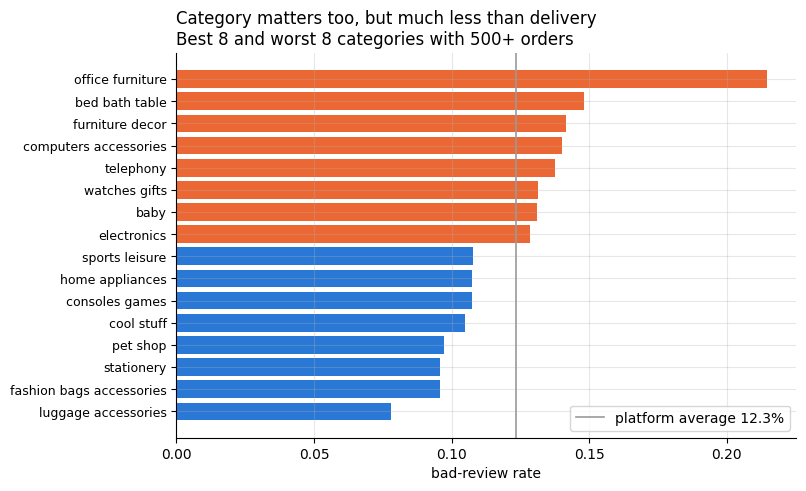

In [15]:
# EDA 3: which categories get the worst reviews? (the second factor we must control for)
cat_tbl = (df[df.category != "unknown"]                       # drop the missing-category bucket
           .groupby("category").is_bad.agg(orders="size", bad_rate="mean")
           .query("orders >= 500").sort_values("bad_rate"))
worst, best = cat_tbl.tail(8), cat_tbl.head(8)
show = pd.concat([best, worst])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(show)), show.bad_rate,
        color=[BLUE] * len(best) + [ORANGE] * len(worst))
ax.axvline(BAD_RATE, color=GREY, lw=1.2, label=f"platform average {BAD_RATE:.1%}")
ax.set_yticks(range(len(show)))
ax.set_yticklabels([c.replace("_", " ") for c in show.index], fontsize=9)
ax.set_xlabel("bad-review rate"); ax.legend(loc="lower right")
ax.set_title("Category matters too, but much less than delivery\n"
             "Best 8 and worst 8 categories with 500+ orders", loc="left")
plt.savefig(FIGS / "eda3_categories.png", bbox_inches="tight"); plt.show()

count    2944.000000
mean       32.120584
std       102.724844
min         1.000000
50%         7.000000
90%        70.700000
99%       385.710000
max      1774.000000

sellers with 10+ orders: 1,214 covering 93.7% of orders


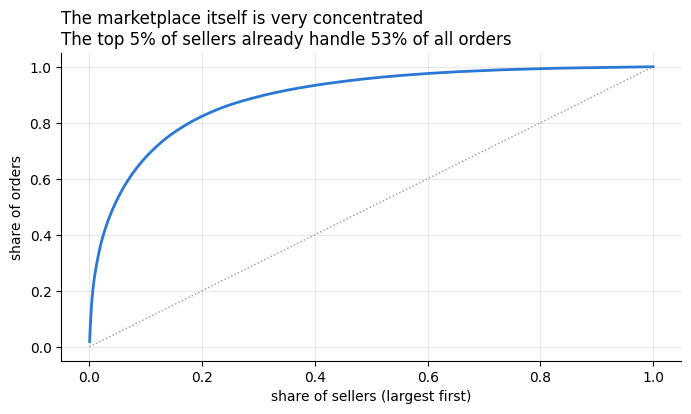

In [16]:
# EDA 4: how big is a typical seller? (small sellers make rate rankings unreliable)
vol = df.groupby("seller_id").size().sort_values(ascending=False)
print(vol.describe(percentiles=[.5, .9, .99]).to_string())
print(f"\nsellers with 10+ orders: {(vol >= 10).sum():,} "
      f"covering {vol[vol >= 10].sum() / vol.sum():.1%} of orders")

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(vol) + 1) / len(vol), vol.cumsum() / vol.sum(), color=BLUE, lw=2)
ax.plot([0, 1], [0, 1], color=GREY, lw=1, ls=":")
ax.set_xlabel("share of sellers (largest first)"); ax.set_ylabel("share of orders")
ax.set_title("The marketplace itself is very concentrated\n"
             "The top 5% of sellers already handle 53% of all orders", loc="left")
plt.savefig(FIGS / "eda4_seller_size.png", bbox_inches="tight"); plt.show()

### EDA summary

| Finding | What we do about it |
|---|---|
| Reviews are U-shaped; the mean sits in an empty gap | Measure the **rate of 1-2 star reviews**, not the average score |
| Late delivery swings the bad-review rate from 8% to 79% | **Control for delivery band** before blaming any seller |
| Category swings it from ~8% to ~21% | **Control for category** too |
| Half of sellers have fewer than 9 orders | Use a **10-order floor** for any rate ranking |
| Order volume is itself concentrated (top 5% = 53% of orders) | Always compare damage share against **order share** |

## 7. Preprocessing for the questions: expected vs actual

In [17]:
# Give every order an EXPECTED bad-review rate from its category and delivery band only.
# Whatever is left over (actual - expected) is the seller's own contribution.
cat_base = df.groupby("category").is_bad.agg(["mean", "size"])
cat_base["p"] = ((cat_base["mean"] * cat_base["size"] + BAD_RATE * 50)
                 / (cat_base["size"] + 50))                      # smooth small categories
band_base = df.groupby("band", observed=True).is_bad.mean()

df["p_expected"] = np.clip(df.category.map(cat_base.p)
                           * df.band.map(band_base).astype(float) / BAD_RATE, 0.005, 0.95)

print(f"expected bad reviews: {df.p_expected.sum():,.0f}")
print(f"actual bad reviews  : {df.is_bad.sum():,}")
print(f"error               : {abs(df.p_expected.sum() - df.is_bad.sum()) / df.is_bad.sum():.2%}"
      "   <- the model is well calibrated, so the leftover is trustworthy")

expected bad reviews: 11,701
actual bad reviews  : 11,676
error               : 0.21%   <- the model is well calibrated, so the leftover is trustworthy


In [18]:
# Build one row per seller with volume, damage, and the expected-vs-actual comparison.
g = df.groupby("seller_id")
st = pd.DataFrame({
    "n_orders":     g.size(),
    "gmv":          g.gmv.sum(),
    "n_bad":        g.is_bad.sum(),
    "bad_rate":     g.is_bad.mean(),
    "late_rate":    g.is_late.mean(),
    "expected_bad": g.p_expected.sum(),
    "n_categories": g.category.nunique(),
    "top_category": g.category.agg(lambda s: s.mode()[0]),
    "seller_state": g.seller_state.first(),
})
st["expected_bad_rate"] = st.expected_bad / st.n_orders
st["excess_bad"] = st.n_bad - st.expected_bad          # bad reviews the seller cannot blame away

# Bad-review rate on parcels that arrived ON TIME - removes the delivery excuse entirely.
ontime = df[~df.is_late].groupby("seller_id").is_bad.agg(["size", "mean"])
st["n_ontime"] = ontime["size"].reindex(st.index).fillna(0).astype(int)
st["bad_rate_ontime"] = ontime["mean"].reindex(st.index)

st = st.reset_index()
qual = st[st.n_orders >= 10].copy()                    # only these can be ranked on a rate
print(f"{len(st):,} sellers | {len(qual):,} with 10+ orders")
st.head(3)

2,944 sellers | 1,214 with 10+ orders


,seller_id,n_orders,gmv,n_bad,bad_rate,late_rate,expected_bad,n_categories,top_category,seller_state,expected_bad_rate,excess_bad,n_ontime,bad_rate_ontime
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2685.00,1,0.333333,0.000000,0.222405,1,small_appliances,SP,0.074135,0.777595,3,0.333333
1,001cca7ae9ae17fb1caed9dfb1094831,191,24037.13,26,0.136126,0.057592,20.228196,2,garden_tools,ES,0.105907,5.771804,180,0.133333
2,002100f778ceb8431b7a1020ff7ab48f,48,1158.80,6,0.125000,0.187500,10.681708,1,furniture_decor,SP,0.222536,-4.681708,39,0.051282


## 8. Question 1 — How concentrated is the damage across sellers?

In [19]:
# Compare the damage share of the worst sellers against their ORDER share (the fair benchmark).
def curve(col):
    v = st.sort_values(col, ascending=False)[col].clip(lower=0)
    return np.arange(1, len(v) + 1) / len(v), v.cumsum().values / v.sum()

x_bad, y_bad = curve("n_bad")
x_ord, y_ord = curve("n_orders")
x_exc, y_exc = curve("excess_bad")
at = lambda f, x, y: float(np.interp(f, x, y))

conc = pd.DataFrame([{
    "worst_x_pct": f"{f:.0%}",
    "sellers": int(f * len(st)),
    "share_of_bad_reviews": at(f, x_bad, y_bad),
    "share_of_orders": at(f, x_ord, y_ord),
    "difference_pp": (at(f, x_bad, y_bad) - at(f, x_ord, y_ord)) * 100,
    "share_of_excess_damage": at(f, x_exc, y_exc),
} for f in (0.01, 0.05, 0.10, 0.20)])
print(conc.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
print(f"\ntotal excess damage available to fix: {st.excess_bad.clip(lower=0).sum():,.0f} bad reviews "
      f"({st.excess_bad.clip(lower=0).sum() / st.n_bad.sum():.0%} of all bad reviews)")

worst_x_pct  sellers  share_of_bad_reviews  share_of_orders  difference_pp  share_of_excess_damage
         1%       29                 0.290            0.263          2.730                   0.350
         5%      147                 0.581            0.529          5.126                   0.651
        10%      294                 0.728            0.677          5.104                   0.803
        20%      588                 0.864            0.823          4.009                   0.944

total excess damage available to fix: 1,931 bad reviews (17% of all bad reviews)


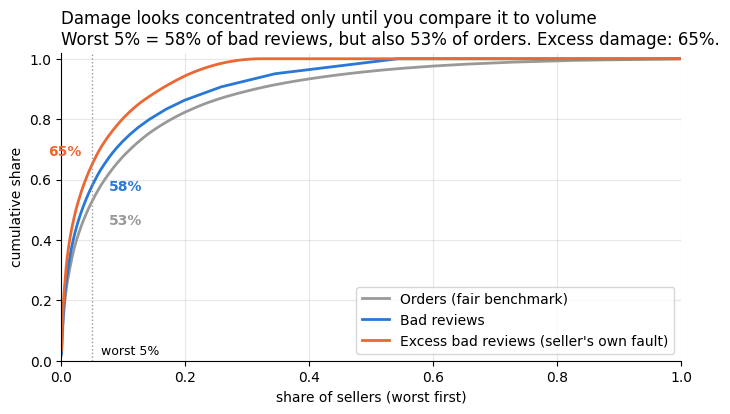

In [20]:
# Chart the same thing: damage barely outruns volume, but EXCESS damage really is concentrated.
fig, ax = plt.subplots()
ax.plot(x_ord, y_ord, color=GREY,   lw=2, label="Orders (fair benchmark)")
ax.plot(x_bad, y_bad, color=BLUE,   lw=2, label="Bad reviews")
ax.plot(x_exc, y_exc, color=ORANGE, lw=2, label="Excess bad reviews (seller's own fault)")
ax.axvline(0.05, color=GREY, lw=1, ls=":")
# The curves rise steeply here, so the top label goes LEFT of the marker and the other
# two go right and staggered - otherwise each label lands on its own line.
for xs, ys, c, dx, dy, ha in [(x_exc, y_exc, ORANGE, -8, 6, "right"),
                              (x_bad, y_bad, BLUE, 12, -4, "left"),
                              (x_ord, y_ord, GREY, 12, -17, "left")]:
    v = at(0.05, xs, ys)
    ax.annotate(f"{v:.0%}", (0.05, v), xytext=(dx, dy), textcoords="offset points",
                ha=ha, color=c, fontsize=10, weight="bold")
ax.annotate("worst 5%", (0.05, 0.02), xytext=(6, 0), textcoords="offset points", fontsize=9)
ax.set_xlabel("share of sellers (worst first)"); ax.set_ylabel("cumulative share")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc="lower right")
ax.set_title("Damage looks concentrated only until you compare it to volume\n"
             "Worst 5% = 58% of bad reviews, but also 53% of orders. Excess damage: 65%.", loc="left")
plt.savefig(FIGS / "q1_concentration.png", bbox_inches="tight"); plt.show()

In [21]:
# "Worst 5%" means three different things - and they pick almost different companies.
n5q, n5a = int(0.05 * len(qual)), int(0.05 * len(st))
groups = {
    "By bad-review count":   st.nlargest(n5a, "n_bad"),
    "By excess bad reviews": qual.nlargest(n5q, "excess_bad"),
    "By bad-review rate":    qual.nlargest(n5q, "bad_rate"),
}
TO, TB, TG = st.n_orders.sum(), st.n_bad.sum(), st.gmv.sum()
TE = st.excess_bad.clip(lower=0).sum()

defs = pd.DataFrame([{
    "ranked_by": k, "sellers": len(v),
    "share_of_orders": v.n_orders.sum() / TO,
    "share_of_gmv": v.gmv.sum() / TG,
    "share_of_bad_reviews": v.n_bad.sum() / TB,
    "share_of_excess": v.excess_bad.clip(lower=0).sum() / TE,
    "their_bad_rate": v.n_bad.sum() / v.n_orders.sum(),
} for k, v in groups.items()])
print(defs.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

            ranked_by  sellers  share_of_orders  share_of_gmv  share_of_bad_reviews  share_of_excess  their_bad_rate
  By bad-review count      147            0.508         0.447                 0.580            0.498           0.141
By excess bad reviews       60            0.162         0.132                 0.253            0.472           0.193
   By bad-review rate       60            0.024         0.034                 0.070            0.192           0.360


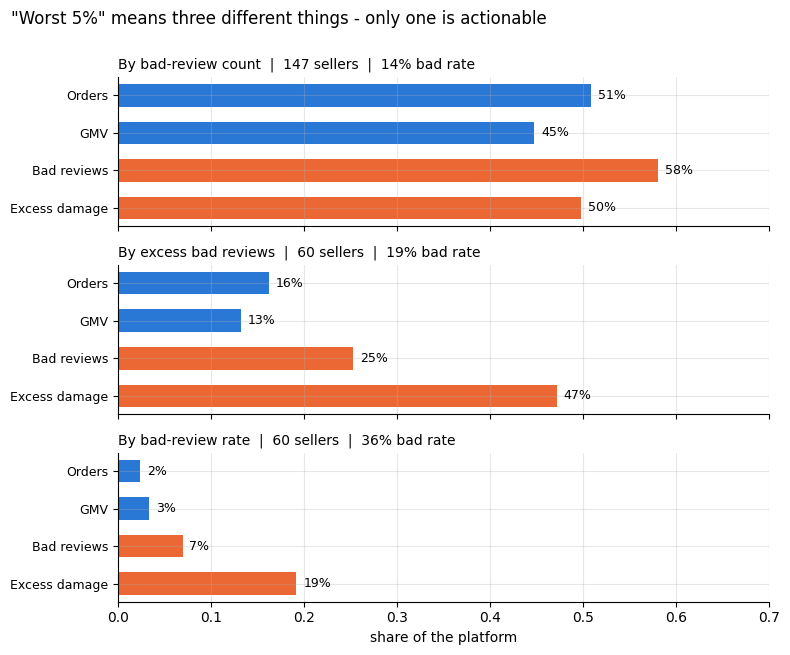

In [22]:
# Chart it: size measures in blue, damage measures in orange - the contrast is the finding.
fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True)
labels = ["Orders", "GMV", "Bad reviews", "Excess damage"]
keys = ["share_of_orders", "share_of_gmv", "share_of_bad_reviews", "share_of_excess"]

for ax, (_, r) in zip(axes, defs.iterrows()):
    vals = [r[k] for k in keys]
    ax.barh(range(4)[::-1], vals, 0.6, color=[BLUE, BLUE, ORANGE, ORANGE])
    for y, v in zip(range(4)[::-1], vals):
        ax.annotate(f"{v:.0%}", (v, y), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=9)
    ax.set_yticks(range(4)[::-1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 0.7)
    ax.set_title(f"{r.ranked_by}  |  {r.sellers} sellers  |  {r.their_bad_rate:.0%} bad rate",
                 fontsize=10, loc="left")
axes[-1].set_xlabel("share of the platform")
fig.suptitle('"Worst 5%" means three different things - only one is actionable',
             fontsize=12, x=0.02, ha="left", y=1.0)
fig.tight_layout()
plt.savefig(FIGS / "q1_definitions.png", bbox_inches="tight"); plt.show()

### Answer to Q1

**Less concentrated than it looks — and the answer depends on how you rank sellers.**

- Worst 5% by **bad-review count** produce **58%** of bad reviews — but they also handle **53%** of
  all orders. The real excess is only **+5 pp**. Ranking this way just finds your biggest sellers.
- Worst 5% by **bad-review rate** are genuinely bad (**36%** vs 12% platform) but handle only
  **2.4%** of orders — too small to move the platform even if deleted.
- Worst 5% by **excess damage** is the actionable cohort: **13%** of GMV and **47%** of all
  avoidable bad reviews.

Total avoidable damage is **1,931 bad reviews (17% of all of them)**. That is the true size of the
seller-side prize — the other 83% is delivery and category, not seller conduct.

## 9. Question 2 — Are certain sellers repeatedly bad regardless of category or delivery time?

We test this four ways. Each test tries to explain the offenders away.

In [23]:
# Define the offender group: sellers whose bad reviews are far above their own expectation.
qual["z"] = ((qual.n_bad - qual.expected_bad)
             / np.sqrt(qual.n_orders * qual.expected_bad_rate * (1 - qual.expected_bad_rate)))
qual["offender"] = (qual.z > 2) & (qual.bad_rate_ontime > BAD_RATE)
off = qual[qual.offender]

print(f"offenders: {len(off)} sellers of {len(qual):,}")
print(f"  orders      {off.n_orders.sum():>7,}  ({off.n_orders.sum()/qual.n_orders.sum():.1%})")
print(f"  GMV         {off.gmv.sum():>10,.0f}  ({off.gmv.sum()/qual.gmv.sum():.1%})")
print(f"  bad reviews {off.n_bad.sum():>7,}  ({off.n_bad.sum()/qual.n_bad.sum():.1%})")
print(f"  excess      {off.excess_bad.sum():>7,.0f}  "
      f"({off.excess_bad.sum()/qual.excess_bad.clip(lower=0).sum():.1%} of avoidable damage)")

offenders: 77 sellers of 1,214
  orders       10,225  (11.5%)
  GMV          1,272,554  (10.9%)
  bad reviews   2,264  (20.6%)
  excess          855  (53.0% of avoidable damage)


In [24]:
# Test 1: is it just chance? Compare how many extreme sellers we see vs what randomness allows.
for thr in (2, 3, 4):
    print(f"  z > {thr}: observed {int((qual.z > thr).sum()):>3} sellers | "
          f"expected by chance {len(qual)*(1-stats.norm.cdf(thr)):>5.1f}")
print(f"\nsellers z < -2 (unusually GOOD): {int((qual.z < -2).sum())}")
print(f"skew of z: {stats.skew(qual.z):.2f}  <- random noise would be 0, so the tail is real")

  z > 2: observed  79 sellers | expected by chance  27.6
  z > 3: observed  33 sellers | expected by chance   1.6
  z > 4: observed  13 sellers | expected by chance   0.0

sellers z < -2 (unusually GOOD): 34
skew of z: 1.68  <- random noise would be 0, so the tail is real


In [25]:
# Test 2: is it the delivery? Compare offenders vs others on parcels that arrived ON TIME.
d = df[df.seller_id.isin(qual.seller_id)].copy()
d["group"] = np.where(d.seller_id.isin(off.seller_id), "Offenders", "Other sellers")
ot = d[~d.is_late]
print(ot.groupby("group").is_bad.agg(orders="size", bad_rate="mean")
      .to_string(float_format=lambda v: f"{v:,.4f}"))
r = ot.groupby("group").is_bad.mean()
print(f"\noffenders are {r['Offenders']/r['Other sellers']:.1f}x worse even with no late delivery")
o_all = df[df.seller_id.isin(off.seller_id)]
print(f"{o_all[~o_all.is_late].is_bad.sum()/o_all.is_bad.sum():.0%} of their bad reviews are on "
      "parcels that were never late")

               orders  bad_rate
group                          
Offenders        9478    0.1841
Other sellers   73184    0.0756

offenders are 2.4x worse even with no late delivery
77% of their bad reviews are on parcels that were never late


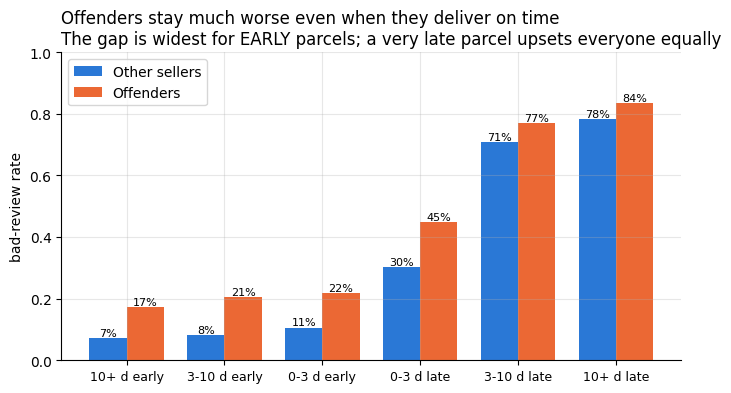

In [26]:
# Chart test 2: the gap holds in every delivery band, and is widest when parcels arrive EARLY.
piv = (d.groupby(["band", "group"], observed=True).is_bad.agg(["size", "mean"]).reset_index())
piv = piv[piv["size"] >= 15]
bands = list(df.band.cat.categories)
xs, w = np.arange(len(bands)), 0.38

fig, ax = plt.subplots()
for grp, colr, off_x in [("Other sellers", BLUE, -w/2), ("Offenders", ORANGE, w/2)]:
    vals = piv[piv.group == grp].set_index("band").reindex(bands)["mean"]
    ax.bar(xs + off_x, vals, w, color=colr, label=grp)
    for x, v in zip(xs + off_x, vals):
        if pd.notna(v):
            ax.annotate(f"{v:.0%}", (x, v), ha="center", va="bottom", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(bands, fontsize=9)
ax.set_ylabel("bad-review rate"); ax.set_ylim(0, 1.0); ax.legend(loc="upper left")
ax.set_title("Offenders stay much worse even when they deliver on time\n"
             "The gap is widest for EARLY parcels; a very late parcel upsets everyone equally",
             loc="left")
plt.savefig(FIGS / "q2_delivery_test.png", bbox_inches="tight"); plt.show()

In [27]:
# Test 3: is it the category? Compare each seller with the categories it actually sells.
df["cat_rate"] = df.category.map(df.groupby("category").is_bad.mean())
comp = df.groupby("seller_id").agg(actual=("is_bad", "mean"), expected_from_category=("cat_rate", "mean"))
comp["group"] = np.where(comp.index.isin(off.seller_id), "Offenders",
                         np.where(comp.index.isin(qual.seller_id), "Other sellers", "too small"))
print(comp[comp.group != "too small"].groupby("group")
      .agg(sellers=("actual", "size"), actual_bad_rate=("actual", "mean"),
           expected_from_category=("expected_from_category", "mean"))
      .to_string(float_format=lambda v: f"{v:,.4f}"))

# The harder test: is a multi-category offender bad in EVERY category it sells?
seg = (df[df.seller_id.isin(off.seller_id)].groupby(["seller_id", "category"])
       .agg(n=("is_bad", "size"), rate=("is_bad", "mean"), base=("cat_rate", "first")).reset_index())
seg = seg[seg.n >= 5]
per = seg.assign(worse=seg.rate > seg.base).groupby("seller_id").agg(
    tested=("category", "size"), worse=("worse", "sum"))
multi = per[per.tested >= 2]
print(f"\noffenders selling 2+ categories        : {len(multi)}")
print(f"  worse than baseline in ALL of them   : {(multi.worse == multi.tested).sum()} "
      f"({(multi.worse == multi.tested).mean():.0%})")

               sellers  actual_bad_rate  expected_from_category
group                                                          
Offenders           77           0.2815                  0.1274
Other sellers     1137           0.1065                  0.1190

offenders selling 2+ categories        : 32
  worse than baseline in ALL of them   : 13 (41%)


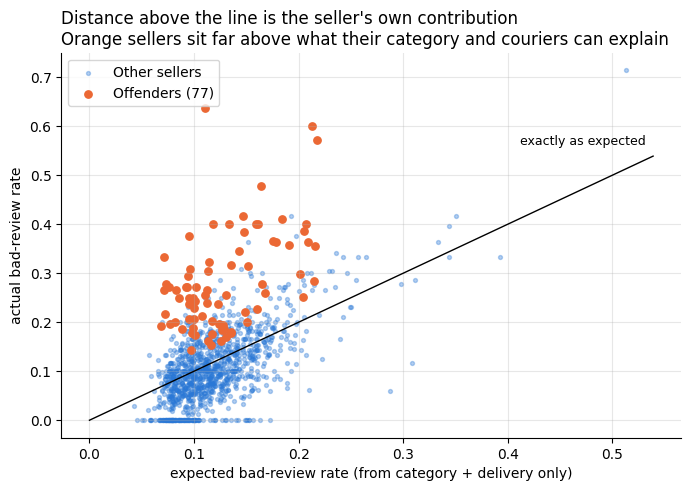

In [28]:
# Chart test 3: every seller's actual bad rate vs what its category and delivery predict.
fig, ax = plt.subplots(figsize=(8, 5))
m = qual.offender
ax.scatter(qual.expected_bad_rate[~m], qual.bad_rate[~m], s=8, color=BLUE, alpha=0.35,
           label="Other sellers")
ax.scatter(qual.expected_bad_rate[m], qual.bad_rate[m], s=28, color=ORANGE,
           label=f"Offenders ({len(off)})")
lim = qual.expected_bad_rate.max() * 1.05
ax.plot([0, lim], [0, lim], color="black", lw=1)
ax.annotate("exactly as expected", (lim, lim), xytext=(-5, 8), textcoords="offset points",
            ha="right", fontsize=9)
ax.set_xlabel("expected bad-review rate (from category + delivery only)")
ax.set_ylabel("actual bad-review rate"); ax.legend()
ax.set_title("Distance above the line is the seller's own contribution\n"
             "Orange sellers sit far above what their category and couriers can explain", loc="left")
plt.savefig(FIGS / "q2_expected_vs_actual.png", bbox_inches="tight"); plt.show()

In [29]:
# Test 4: does it repeat over time? Split each seller's history in half and compare the halves.
b = df.sort_values("order_purchase_timestamp").copy()
b["i"] = b.groupby("seller_id").cumcount()
b["n"] = b.seller_id.map(b.groupby("seller_id").size())
b["half"] = np.where(b.i < b.n / 2, "H1", "H2")

sp = b[b.n >= 20].pivot_table(index="seller_id", columns="half", values="is_bad", aggfunc="mean").dropna()
print(f"sellers with 20+ orders: {len(sp):,}")
print(f"correlation between first-half and second-half bad rate: "
      f"r = {stats.pearsonr(sp.H1, sp.H2)[0]:.3f}")

QL = ["Q1 best", "Q2", "Q3", "Q4 worst"]
sp["q1"] = pd.qcut(sp.H1.rank(method="first"), 4, labels=QL)
sp["q2"] = pd.qcut(sp.H2.rank(method="first"), 4, labels=QL)
trans = pd.crosstab(sp.q1, sp.q2, normalize="index")
print("\nwhere a seller ends up in the second half (row %):")
print((trans * 100).round(0).to_string())
print(f"\nworst quartile stays worst: {trans.loc['Q4 worst','Q4 worst']:.0%} "
      f"(random would be 25%)")

sellers with 20+ orders: 784
correlation between first-half and second-half bad rate: r = 0.281

where a seller ends up in the second half (row %):
q2        Q1 best    Q2    Q3  Q4 worst
q1                                     
Q1 best      39.0  24.0  20.0      17.0
Q2           23.0  31.0  27.0      19.0
Q3           19.0  25.0  32.0      24.0
Q4 worst     19.0  20.0  22.0      39.0

worst quartile stays worst: 39% (random would be 25%)


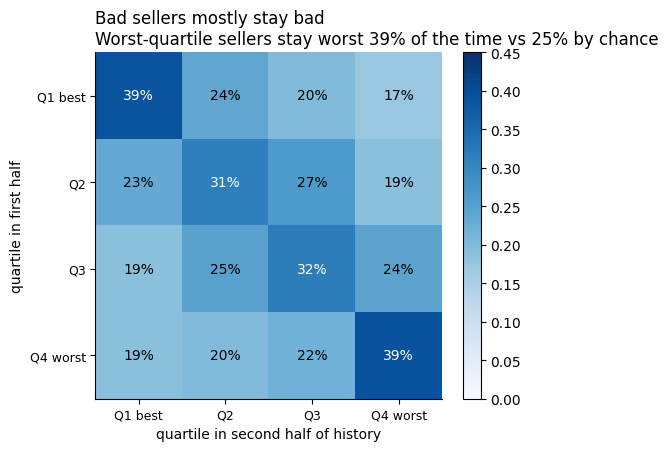

In [30]:
# Chart test 4: the darker diagonal shows sellers mostly stay where they were.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(trans.values, cmap="Blues", vmin=0, vmax=0.45)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{trans.values[i, j]:.0%}", ha="center", va="center", fontsize=10,
                color="white" if trans.values[i, j] > 0.28 else "black")
ax.set_xticks(range(4)); ax.set_xticklabels(QL, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(QL, fontsize=9)
ax.set_xlabel("quartile in second half of history"); ax.set_ylabel("quartile in first half")
ax.grid(False)
ax.set_title("Bad sellers mostly stay bad\n"
             "Worst-quartile sellers stay worst 39% of the time vs 25% by chance", loc="left")
plt.colorbar(im, ax=ax, fraction=0.045)
plt.savefig(FIGS / "q2_persistence.png", bbox_inches="tight"); plt.show()

### Answer to Q2

**Yes — and every attempt to explain it away fails.**

| Test | Result |
|---|---|
| **Chance?** | **33** sellers sit 3+ standard deviations above their own expectation; chance allows **1.6**. The z distribution is skewed +1.68 where pure noise would be 0 |
| **Delivery?** | On parcels that arrived on time, offenders run **18.4%** vs **7.6%** — **2.4× worse**. **77%** of their bad reviews are on parcels that were never late |
| **Category?** | Their own categories predict **12.7%**; they deliver **28.2%**. Of the 32 offenders selling 2+ categories, **41% are worse than baseline in every single category** (and most of the rest in some) |
| **One bad patch?** | Worst-quartile sellers stay worst-quartile **39%** of the time vs 25% by chance (r = 0.28 between halves) |

The problem travels with the seller, not with the product or the courier.

## 10. The action list

In [31]:
# Sort offenders into WHY they fail - this decides the intervention for each one.
off = off.copy()
off["failure_mode"] = np.select(
    [(off.late_rate > 2 * df.is_late.mean()) & (off.bad_rate_ontime > 2 * BAD_RATE),
     off.bad_rate_ontime > 2 * BAD_RATE,
      off.late_rate > 2 * df.is_late.mean()],
    ["MIXED - both problems", "PRODUCT - item disappoints", "FULFILMENT - ships slowly"],
    default="BORDERLINE - watch")

print(off.groupby("failure_mode")
      .agg(sellers=("seller_id", "size"), orders=("n_orders", "sum"),
           bad_rate=("bad_rate", "mean"), bad_rate_ontime=("bad_rate_ontime", "mean"),
           late_rate=("late_rate", "mean"), excess_bad=("excess_bad", "sum"))
      .sort_values("excess_bad", ascending=False)
      .to_string(float_format=lambda v: f"{v:,.3f}"))

                            sellers  orders  bad_rate  bad_rate_ontime  late_rate  excess_bad
failure_mode                                                                                 
BORDERLINE - watch               37    8418     0.206            0.177      0.056     507.516
PRODUCT - item disappoints       26     894     0.331            0.318      0.037     197.057
MIXED - both problems             9     459     0.429            0.357      0.190     107.182
FULFILMENT - ships slowly         5     454     0.314            0.206      0.157      43.241


In [32]:
# Compare the two possible actions: coach the seller, or remove it from the platform.
median_rate = qual.bad_rate.median()
coach_avoided = off.n_bad.sum() - off.n_orders.sum() * median_rate
coach_rate  = (TB - coach_avoided) / TO
delist_rate = (TB - off.n_bad.sum()) / (TO - off.n_orders.sum())

print(f"today                      : bad rate {BAD_RATE:.2%}")
print(f"coach offenders to median  : bad rate {coach_rate:.2%}  "
      f"({(coach_rate-BAD_RATE)*100:+.2f} pp)  GMV lost: none")
print(f"delist offenders           : bad rate {delist_rate:.2%}  "
      f"({(delist_rate-BAD_RATE)*100:+.2f} pp)  GMV lost: {off.gmv.sum()/TG:.1%}")
print("\n-> coaching wins: a bigger improvement AND no lost revenue.")
print("   (Delisting also removes the offenders' many satisfactory orders, so the rate improves less.)")

today                      : bad rate 12.35%
coach offenders to median  : bad rate 11.05%  (-1.30 pp)  GMV lost: none
delist offenders           : bad rate 11.16%  (-1.19 pp)  GMV lost: 9.9%

-> coaching wins: a bigger improvement AND no lost revenue.
   (Delisting also removes the offenders' many satisfactory orders, so the rate improves less.)


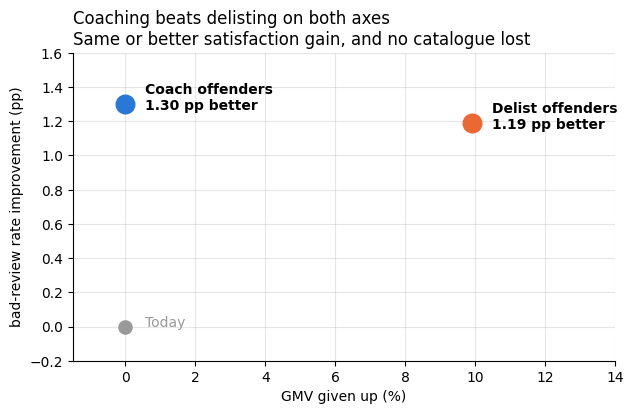

In [33]:
# Chart the trade-off: coaching gets more improvement for zero revenue cost.
fig, ax = plt.subplots(figsize=(7, 4))
opts = [("Coach offenders", 0.0, (BAD_RATE - coach_rate) * 100, BLUE),
        ("Delist offenders", off.gmv.sum() / TG * 100, (BAD_RATE - delist_rate) * 100, ORANGE)]
for name, gx, gy, colr in opts:
    ax.scatter([gx], [gy], s=180, color=colr, zorder=5)
    ax.annotate(f"{name}\n{gy:.2f} pp better", (gx, gy), xytext=(14, -4),
                textcoords="offset points", fontsize=10, weight="bold")
ax.scatter([0], [0], s=90, color=GREY, zorder=5)
ax.annotate("Today", (0, 0), xytext=(14, 0), textcoords="offset points", fontsize=10, color=GREY)
ax.set_xlim(-1.5, 14); ax.set_ylim(-0.2, 1.6)
ax.set_xlabel("GMV given up (%)"); ax.set_ylabel("bad-review rate improvement (pp)")
ax.set_title("Coaching beats delisting on both axes\n"
             "Same or better satisfaction gain, and no catalogue lost", loc="left")
plt.savefig(FIGS / "q2_action.png", bbox_inches="tight"); plt.show()

In [34]:
# The final list, and save it to CSV.
cols = ["seller_id", "failure_mode", "seller_state", "top_category", "n_orders", "gmv",
        "bad_rate", "expected_bad_rate", "bad_rate_ontime", "late_rate", "excess_bad", "z"]
final = off[cols].sort_values("excess_bad", ascending=False)
final.to_csv("seller_watchlist.csv", index=False)

show = final.head(12).copy()
show["seller_id"] = show.seller_id.str[:8] + "..."
show["top_category"] = show.top_category.str.replace("_", " ")
print("Top 12 sellers to act on (by excess bad reviews):\n")
print(show.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nfull list of {len(final)} sellers saved to seller_watchlist.csv")

Top 12 sellers to act on (by excess bad reviews):

  seller_id               failure_mode seller_state          top_category  n_orders        gmv  bad_rate  expected_bad_rate  bad_rate_ontime  late_rate  excess_bad     z
6560211a...         BORDERLINE - watch           SP         watches gifts      1774 118,034.83      0.15               0.12             0.13       0.05       67.06  4.97
2eb70248... PRODUCT - item disappoints           SP         watches gifts       182  37,485.15      0.48               0.16             0.45       0.11       57.10 11.42
7c67e144...         BORDERLINE - watch           SP      office furniture       957 183,260.89      0.25               0.20             0.20       0.09       44.75  3.59
1ca7077d...      MIXED - both problems           SP               unknown       105  12,174.64      0.60               0.21             0.54       0.17       40.68  9.70
5dceca12...         BORDERLINE - watch           SP   luggage accessories       313 106,412.33     

## 11. Conclusions

**Q1 — Concentration.** Damage is *less* concentrated than it appears. The worst 5% of sellers by
bad-review count produce 58% of bad reviews but handle 53% of orders, so the genuine excess is only
+5 pp. Real concentration shows up only after subtracting what category and delivery already
explain: on that measure the worst 5% own **65%** of avoidable damage. Total avoidable damage is
**1,931 bad reviews, 17% of all of them.**

**Q2 — Recurrence.** Yes. A group of **77 sellers** is repeatedly and measurably worse than its own
category and delivery record predicts. They hold **11% of GMV** but **53% of all avoidable damage**,
and they stay **2.4× worse** even when their parcels arrive on time.

**What to do**

1. Track **excess bad reviews**, not raw complaint counts — counts just point at your biggest sellers.
2. **Coach the 77 sellers rather than delisting them**: better satisfaction gain, zero GMV lost.
3. **Split by failure mode** — the 5 fulfilment cases need a shipping SLA, but the 26 **product**
   cases ship late only 3.7% of the time and are still disliked 32% of the time, so an SLA would do
   nothing for them; they need a listing and quality review.
4. Add the **on-time bad-review rate** to the seller scorecard. It is the single most useful field
   here, and it needs no model.
5. **Expect limited upside from seller action alone**: coaching all 77 moves the platform from
   **12.35% to 11.05%** — about **1.3 points**. Delivery timing is the bigger lever.

**Limitations**

- 1.3% of orders involve several sellers and were dropped, since one review cannot be split between
  them. Those orders have a 47% bad-review rate, so the platform's true rate is 12.8% and our
  seller figures are conservative. **This is worth investigating separately.**
- The expected-rate model controls for category and delivery only; price, product weight and freight
  are not controlled.
- Sellers with few orders have noisy rates, which is why the list requires 10+ orders and a
  statistical threshold rather than a raw rate.
- Coaching gains are a "what if they matched the median" estimate, not a measured result.